# Fit Literature vs Fitted

In [1]:
import os
import sys
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
_REPO_ROOT = os.path.abspath(".")
sys.path.insert(0, os.path.join(_REPO_ROOT, "src"))
FIXED_DIR = os.path.join(_REPO_ROOT, "results", "fixed_estimation")
FIRST_ESTIMATION_DIR = os.path.join(_REPO_ROOT, "results", "first_estimation")
SECOND_ESTIMATION_DIR = os.path.join(_REPO_ROOT, "results", "second_estimation")
THIRD_ESTIMATION_DIR = os.path.join(_REPO_ROOT, "results", "third_estimation")
RESULTS_DIR = os.path.join(_REPO_ROOT, "results", "final_analysis")
BOOSTRAPPING_DIR = os.path.join(_REPO_ROOT, "results", "bootstrap_estimation")
os.makedirs(RESULTS_DIR, exist_ok=True)

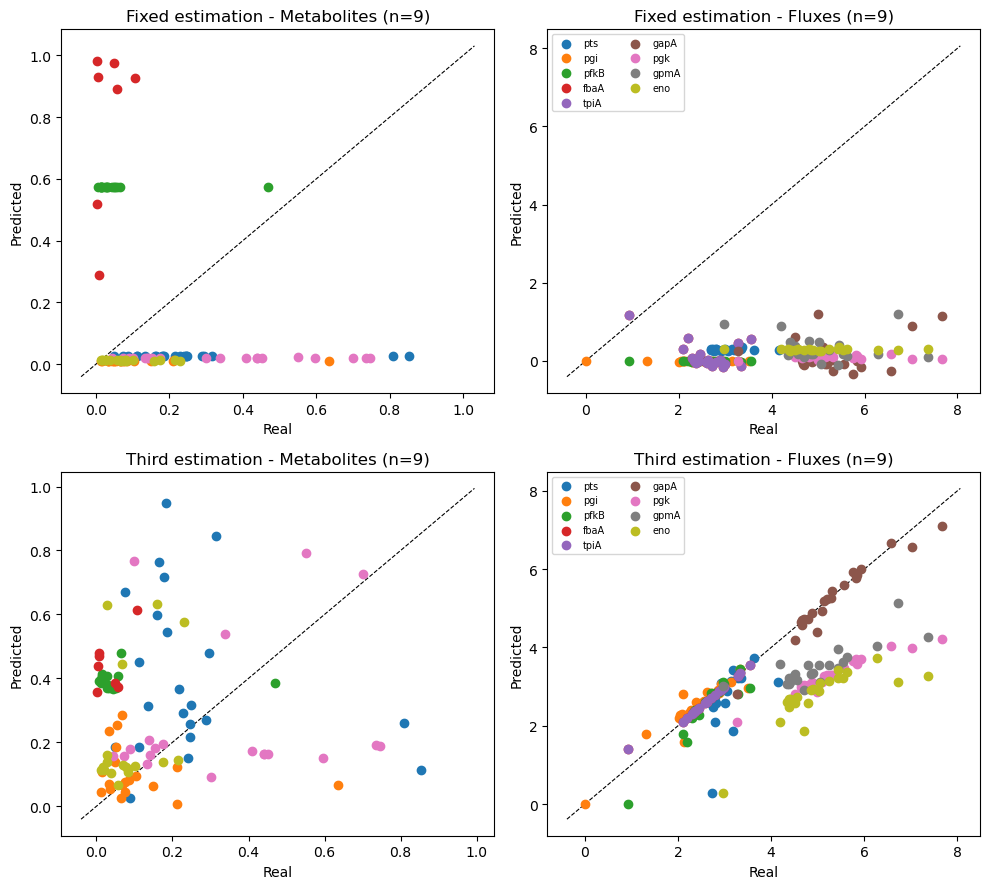

In [2]:
# Parity plots (predicted vs real): row 0 = fixed estimation, row 1 = third estimation
pred_fixed = pd.read_csv(os.path.join(FIXED_DIR, "predictions.csv"), index_col=0)
real_fixed = pd.read_csv(os.path.join(FIXED_DIR, "real.csv"), index_col=0)
pred_third = pd.read_csv(os.path.join(THIRD_ESTIMATION_DIR, "predictions_fitted.csv"), index_col=0)
real_third = pd.read_csv(os.path.join(THIRD_ESTIMATION_DIR, "real.csv"), index_col=0)

colors = plt.get_cmap("tab10").colors

def parity_row(ax_met, ax_flux, real, pred):
    met_count = 0
    flux_count = 0
    for column in pred.columns:
        name = column.split('_')[1]
        if column.startswith('C_'):
            ax_met.scatter(real[column], pred[column], color=colors[met_count % 10], label=name)
            met_count += 1
        else:
            ax_flux.scatter(real[column], pred[column], color=colors[flux_count % 10], label=name)
            flux_count += 1

    for ax in (ax_met, ax_flux):
        lo = min(ax.get_xlim()[0], ax.get_ylim()[0])
        hi = max(ax.get_xlim()[1], ax.get_ylim()[1])
        ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, zorder=0)
        ax.set_xlabel("Real")
        ax.set_ylabel("Predicted")

    return met_count, flux_count

fig, ax = plt.subplots(2, 2, figsize=(10, 9))

n_met, n_flux = parity_row(ax[0, 0], ax[0, 1], real_fixed, pred_fixed)
ax[0, 0].set_title(f"Fixed estimation - Metabolites (n={n_met})")
ax[0, 1].set_title(f"Fixed estimation - Fluxes (n={n_flux})")

n_met, n_flux = parity_row(ax[1, 0], ax[1, 1], real_third, pred_third)
ax[1, 0].set_title(f"Third estimation - Metabolites (n={n_met})")
ax[1, 1].set_title(f"Third estimation - Fluxes (n={n_flux})")

ax[0, 1].legend(fontsize=7, ncol=2)
ax[1, 1].legend(fontsize=7, ncol=2)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "parity_fixed_vs_third.png"), dpi=200)
plt.show()

# FIM Char

In [3]:
fim_first = pd.read_csv(os.path.join(FIRST_ESTIMATION_DIR, "fim.csv"), index_col=0)
print('FIRST ESTIMATION MATRIX')
print('Shape FIM', fim_first.shape)
print('FIM rank', np.linalg.matrix_rank(fim_first.values))
print('FIM determinant', np.linalg.det(fim_first.values))
fim_second = pd.read_csv(os.path.join(SECOND_ESTIMATION_DIR, "fim.csv"), index_col=0)
print('SECOND ESTIMATION MATRIX')
print('Shape FIM', fim_second.shape)
print('FIM rank', np.linalg.matrix_rank(fim_second.values))
print('FIM determinant', np.linalg.det(fim_second.values))
fim_third = pd.read_csv(os.path.join(THIRD_ESTIMATION_DIR, "fim.csv"), index_col=0)
print('THIRD ESTIMATION MATRIX')
print('Shape FIM', fim_third.shape)
print('FIM rank', np.linalg.matrix_rank(fim_third.values))
print('FIM determinant', np.linalg.det(fim_third.values))

FIRST ESTIMATION MATRIX
Shape FIM (37, 37)
FIM rank 18
FIM determinant -1.559964630722886e-251
SECOND ESTIMATION MATRIX
Shape FIM (18, 18)
FIM rank 13
FIM determinant 7.30221484269104e-58
THIRD ESTIMATION MATRIX
Shape FIM (16, 16)
FIM rank 13
FIM determinant 1.4749992186009088e-37


# Confidence coefficient distribution evolution

In [4]:
theta_first = pd.read_csv(os.path.join(FIRST_ESTIMATION_DIR, "theta_fitted.csv"), index_col=0)
theta_second = pd.read_csv(os.path.join(SECOND_ESTIMATION_DIR, "theta_fitted.csv"), index_col=0)
theta_third = pd.read_csv(os.path.join(THIRD_ESTIMATION_DIR, "theta_fitted.csv"), index_col=0)

boostrap_first = pd.read_csv(os.path.join(BOOSTRAPPING_DIR, "bootstrap_theta_first_estimation.csv"))
boostrap_second = pd.read_csv(os.path.join(BOOSTRAPPING_DIR, "bootstrap_theta_second_estimation.csv"))
boostrap_third = pd.read_csv(os.path.join(BOOSTRAPPING_DIR, "bootstrap_theta_third_estimation.csv"))

In [5]:
boostrap_first

,v_max_1,Ka1_1,Ka2_1,Ka3_1,K_g6p_1,Ks_g6p_pgi,Kp_f6p_pgi,kcat_f_2,Ks_f6p_3,Ks_atp_3,...,Ks_adp_7,Ks_3pg_7,Ks_atp_7,kcat_f_8,Ks_3pg_8,Ks_2pg_8,kcat_f_9,Ks_2pg_9,Ks_pep_9,obj_value
0,71.217579,0.117711,0.521334,3.882753,10.078869,8.754545,10.035708,547.500287,0.694912,1.635289,...,0.001244,9.994463,9.995872,617.656906,3.574691,10.000707,482.423563,0.337631,10.082627,184.704540
1,78.572447,0.091513,0.391485,5.706713,10.517465,5.093545,10.374339,626.571305,1.056562,1.333910,...,0.005266,10.736319,10.706791,662.322478,2.393735,9.993257,316.294840,3.768288,8.980280,108.767360
2,75.540651,0.601537,0.542001,6.556028,10.111069,7.306592,10.037482,590.109433,0.581247,2.028393,...,0.001151,10.017464,10.015091,500.637353,9.117774,9.999733,447.163054,3.698368,9.911305,263.335323
3,78.105908,0.669194,0.678003,6.102621,10.087329,7.529234,10.030026,583.993551,1.026517,1.026517,...,0.001150,10.015766,10.015766,682.918583,3.028035,10.025561,590.106145,7.021108,10.035679,116.089343
4,81.595908,0.001968,0.218064,4.660255,11.273109,6.789536,10.016978,487.726733,0.702750,1.861608,...,0.001653,9.491802,9.368981,563.717074,3.073140,9.951063,242.762508,0.001618,7.505075,74.075654
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4983,77.175677,0.269455,0.342077,5.638130,10.747837,7.498461,10.031145,523.911559,0.203248,1.910168,...,0.001941,9.707637,9.635836,604.075865,3.628788,9.976878,335.252234,0.684438,8.469427,10.104715
4984,77.717541,0.843526,0.774139,5.931682,10.452914,7.216678,10.041046,565.152899,0.339112,1.500839,...,0.001340,9.862353,9.825455,627.730814,3.098349,10.002885,432.682984,2.849899,9.192363,11.106263
4985,76.409438,0.004702,0.015381,5.479795,10.945285,3.088662,10.101260,513.119628,0.655937,2.052165,...,0.001946,9.622330,9.530303,542.946958,3.891345,9.963308,289.950292,0.002679,8.067155,95.098537
4986,77.095014,0.002047,0.030673,5.861674,10.112349,7.053799,10.043929,579.895481,1.338434,0.896693,...,0.001275,10.022434,10.021745,678.585032,2.875701,10.023957,546.410242,4.887201,9.999293,120.797885


<Axes: >

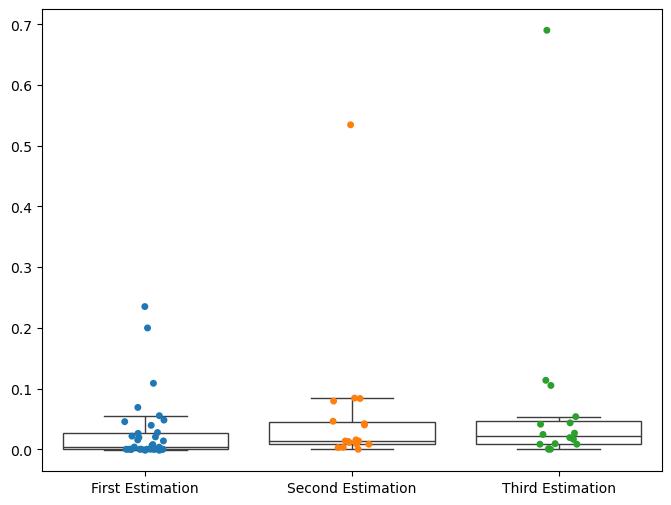

In [6]:
def better_bootstrap_ci(theta_star_df, thetas_beta_df, alpha=0.95):
    # given the B boostrap copies
    # bias corection z0
    # phi^-1 (1/B * sum_{b=1}^B I(theta_hat < theta_hat^*))
    dict_ci = {}
    for param in theta_star_df.index:
        theta_star = theta_star_df.loc[param].values[0]
        thetas_beta = thetas_beta_df[param].values
        mean_thetas = np.mean(thetas_beta < theta_star)
        z0_hat = scipy.stats.norm.ppf(mean_thetas - 1e-12)
        # print(mean_thetas, z0_hat)
        mean_thetas = np.mean(thetas_beta)
        # ahat = np.sum((mean_thetas - thetas_beta) ** 3) / (6 * (np.sum((mean_thetas - thetas_beta) ** 2) ** 1.5))
        ahat = np.sum((mean_thetas - thetas_beta) ** 3) / (6 * (np.sum((mean_thetas - thetas_beta) ** 2) ** 3/2))
        # print(ahat, z0_hat)
        # print((1 - ahat * (z0_hat + scipy.stats.norm.ppf(alpha / 2))))
        alpha_1 = scipy.stats.norm.cdf(
            z0_hat + (z0_hat + scipy.stats.norm.ppf(alpha / 2)) / (1 - ahat * (z0_hat + scipy.stats.norm.ppf(alpha / 2)))
        )
        alpha_2 = scipy.stats.norm.cdf(
            z0_hat + (z0_hat + scipy.stats.norm.ppf(1 - alpha / 2)) / (1 - ahat * (z0_hat + scipy.stats.norm.ppf(1 - alpha / 2)))
        )
        lower_bound = np.percentile(thetas_beta, alpha_1 * 100)
        upper_bound = np.percentile(thetas_beta, alpha_2 * 100)
        c25 = np.percentile(thetas_beta, 25)
        c75 = np.percentile(thetas_beta, 75)
        iqr = c75 - c25
        dict_ci[param] = (theta_star,lower_bound, upper_bound, c25, c75, iqr, (upper_bound - lower_bound) / theta_star)
    pd_CBa = pd.DataFrame.from_dict(dict_ci, orient='index', columns=['Param','lower_bound', 'upper_bound', 'C25', 'C75', 'IQR', 'ConfidenceCoefficient'])
    return pd_CBa
    

pd_CBa_first = better_bootstrap_ci(theta_first, boostrap_first, alpha=0.95)
pd_CBa_second = better_bootstrap_ci(theta_second, boostrap_second, alpha=0.95)
pd_CBa_third = better_bootstrap_ci(theta_third, boostrap_third, alpha=0.95)

confidenceCoeff = pd.concat([pd_CBa_first['ConfidenceCoefficient'], pd_CBa_second['ConfidenceCoefficient'], pd_CBa_third['ConfidenceCoefficient']], axis=1)
confidenceCoeff.columns = ['First Estimation', 'Second Estimation', 'Third Estimation']
fig, ax = plt.subplots(figsize=(8, 6))
sns.stripplot(data=confidenceCoeff, ax=ax)
sns.boxplot(data=confidenceCoeff, ax=ax, whis=1.5, fliersize=0, boxprops={'facecolor':'None'})


In [7]:
pd_CBa_first

,Param,lower_bound,upper_bound,C25,C75,IQR,ConfidenceCoefficient
v_max_1,80.995512,86.627453,88.749126,74.841652,78.202981,3.361330,2.619494e-02
Ka1_1,0.001709,0.001265,0.001300,0.002005,0.132820,0.130815,2.036876e-02
Ka2_1,0.040954,0.026198,0.029021,0.026617,0.393004,0.366388,6.893167e-02
Ka3_1,5.302742,4.240730,4.495785,5.402923,6.137759,0.734836,4.809873e-02
K_g6p_1,11.277738,11.312911,11.312911,10.123521,10.611325,0.487804,5.519676e-09
Ks_g6p_pgi,6.971282,7.074814,7.182206,5.575833,7.402405,1.826572,1.540489e-02
Kp_f6p_pgi,10.053134,10.058020,10.061279,10.038526,10.061857,0.023330,3.242097e-04
kcat_f_2,501.275889,287.417099,298.290671,534.505051,583.157825,48.652774,2.169179e-02
Ks_f6p_3,0.907750,1.124951,1.160788,0.607076,0.845726,0.238651,3.947944e-02
Ks_atp_3,2.110340,2.441831,2.483149,1.334147,2.011222,0.677075,1.957861e-02
